In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Vision–Language Models (VLMs) — A Complete Tutorial

> *"Aligning vision and language: from contrastive pre-training to generative dialogue"*

This notebook accompanies a lecture on multimodal vision–language models. It covers two major paradigms:

| Paradigm | Key idea | Models covered |
|---|---|---|
| **Contrastive VLMs** | Train image + text encoders to align representations via CLIP loss | OpenCLIP (ViT-B-32, ViT-L-14), Jina-CLIP-v2 |
| **Generative/Fused VLMs** | Connect a vision encoder to a language model decoder | SmolVLM-256M, Qwen2-VL-2B, LLaVA-1.5-7B |

**What you will learn:**
- How CLIP trains a shared image–text embedding space and why it enables zero-shot tasks
- Zero-shot image classification with prompt engineering on CIFAR-10
- Cross-modal text → image retrieval over a local image dataset
- How Jina-CLIP-v2 extends CLIP with multilingual and high-resolution support
- How "fused" VLMs (LLaVA-style) connect a frozen vision encoder to a language model
- Image captioning, Visual QA, and multi-turn conversation with small open-source models

All experiments are designed to run on **Apple Silicon M4 (24 GB unified memory)**, NVIDIA CUDA, or CPU.

## 1. Environment Setup

This notebook uses the **[uv](https://github.com/astral-sh/uv)** managed environment from `pyproject.toml`.
Re-run the cell below only if you start from a fresh environment.

In [2]:
# Run only if a library is missing.
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#     "open-clip-torch", "sentence-transformers", "transformers",
#     "torch", "torchvision", "scikit-learn", "matplotlib", "tqdm", "Pillow"])

## 2. Imports & Device

In [3]:
import os, math, warnings
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch import Tensor, no_grad
from torchvision import transforms as T
from torchvision.datasets import CIFAR10

from tqdm.auto import tqdm
from scipy.spatial.distance import cosine
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import open_clip
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
    LlavaForConditionalGeneration,
    Idefics3ForConditionalGeneration,
)

warnings.filterwarnings("ignore")

### Device Detection

We auto-detect the best available hardware:
- **CUDA** — NVIDIA GPU (fastest)
- **MPS** — Apple Silicon M1/M2/M3/M4 (used here)
- **CPU** — universal fallback

In [4]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print(f"Using device: {DEVICE}")
if DEVICE.type == "mps":
    print("Apple Silicon detected — MPS backend active.")
elif DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: mps
Apple Silicon detected — MPS backend active.


### Data Paths

We use **CIFAR-10** (auto-downloaded) for classification and **`data/search/`** local images for retrieval.

In [5]:
DATA_DIR   = Path("data")
SEARCH_DIR = DATA_DIR / "search"
IMG_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp"}

Path("checkpoints/vlm").mkdir(parents=True, exist_ok=True)

## 3. Contrastive Vision–Language Models

### 3.1 The Core Idea: Shared Embedding Space

**CLIP** (*Contrastive Language–Image Pre-training*, Radford et al. 2021) learns a joint embedding space
where images and their matching text descriptions land close together, while mismatched pairs are pushed apart.

```
Training pairs:  ("a photo of a cat", 🐱)  →  close in embedding space
                 ("a photo of a cat", 🐶)  →  far in embedding space
```

### 3.2 Architecture

```
Image  ──►  Image Encoder (ViT)  ──►  image_emb  (D-dim, L2-normalised)
                                               ↘
                                          cosine_similarity  →  InfoNCE loss
                                               ↗
Text   ──►  Text Encoder (Transformer)  ──►  text_emb  (D-dim, L2-normalised)
```

### 3.3 Why Zero-Shot Classification Works

1. For each class, build text prompts: `"a photo of a {class}"` → encode → `text_embs` **(C × D)**
2. Encode the query image → `image_emb` **(1 × D)**
3. Compute cosine similarities → pick the highest-scoring class

No task-specific training needed. The model generalises because the text encoder was exposed
to millions of concept descriptions during pre-training.

### 3.4 Pre-training Datasets

| Model | Dataset | Scale |
|---|---|---|
| OpenAI CLIP | WIT (WebImageText) | 400 M pairs |
| OpenCLIP ViT-B/32 | LAION-2B | 2 B pairs |
| OpenCLIP ViT-L/14 | LAION-2B | 2 B pairs |
| Jina-CLIP-v2 | LAION + proprietary | multilingual, 89+ languages |

## 4. OpenCLIP — Zero-Shot Image Classification

### 4.1 Loading ViT-B/32

We start with **ViT-B/32** on **LAION-2B**: a fast model that demonstrates the core concepts well.

In [6]:
CLIP_B32_NAME      = "ViT-B-32"
CLIP_B32_PRETRAINED = "laion2b_s34b_b79k"

clip_b32, _, clip_b32_preprocess = open_clip.create_model_and_transforms(
    CLIP_B32_NAME, pretrained=CLIP_B32_PRETRAINED
)
clip_b32 = clip_b32.to(DEVICE).eval()
clip_b32_tokenizer = open_clip.get_tokenizer(CLIP_B32_NAME)

n_params = sum(p.numel() for p in clip_b32.parameters()) / 1e6
print(f"Loaded {CLIP_B32_NAME} ({CLIP_B32_PRETRAINED})  |  {n_params:.0f}M parameters")

Loaded ViT-B-32 (laion2b_s34b_b79k)  |  151M parameters


### 4.2 Zero-Shot: Single Image Walkthrough

Before benchmarking, let's walk through every step with **one image** to build intuition.

True : dog
Pred : bird  (29.1%)

All class probabilities:
  bird           29.1%  ███████████
  cat            28.0%  ███████████
  dog            27.1%  ██████████
  horse          15.4%  ██████
  deer            0.1%  
  frog            0.1%  
  automobile      0.0%  
  airplane        0.0%  
  ship            0.0%  
  truck           0.0%  


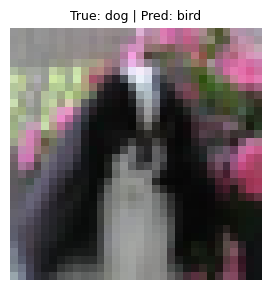

In [7]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Load one test image from CIFAR-10
cifar_raw = CIFAR10(DATA_DIR, train=False, download=True)
sample_img, sample_label = cifar_raw[42]   # PIL Image, integer label

# ── Step 1: Encode the image ──────────────────────────────────────────────────
img_t = clip_b32_preprocess(sample_img).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
with no_grad():
    img_emb = F.normalize(clip_b32.encode_image(img_t), dim=-1)   # (1, D)

# ── Step 2: Encode text prompts for all classes ───────────────────────────────
prompts = [f"a photo of a {c}." for c in CIFAR10_CLASSES]
tokens  = clip_b32_tokenizer(prompts).to(DEVICE)
with no_grad():
    text_embs = F.normalize(clip_b32.encode_text(tokens), dim=-1)  # (C, D)

# ── Step 3: Compute softmax over cosine similarities ─────────────────────────
# logit_scale is a learnable temperature ≈ 100 that sharpens the distribution
scale  = clip_b32.logit_scale.exp().item()
logits = (img_emb @ text_embs.T * scale).softmax(dim=-1).squeeze().cpu()

pred_cls  = CIFAR10_CLASSES[logits.argmax().item()]
true_cls  = CIFAR10_CLASSES[sample_label]
print(f"True : {true_cls}")
print(f"Pred : {pred_cls}  ({logits.max()*100:.1f}%)")
print()
print("All class probabilities:")
for cls, p in sorted(zip(CIFAR10_CLASSES, logits.tolist()), key=lambda x: -x[1]):
    bar = "█" * int(p * 40)
    print(f"  {cls:<12}  {p*100:5.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(sample_img)
ax.set_title(f"True: {true_cls} | Pred: {pred_cls}", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

### 4.3 Prompt Engineering

How you phrase the text prompt **significantly affects accuracy**.

We compare three strategies:
| Strategy | Example | Effect |
|---|---|---|
| Plain class name | `"cat"` | Baseline |
| Single template | `"a photo of a cat."` | +2–4 % |
| Ensemble (7 templates) | Average of 7 phrasings | +1–3 % more |

**Ensemble trick**: average the text embeddings from multiple phrasings before computing similarity.
This smooths out template-specific biases.

In [8]:
PROMPT_ENSEMBLE = [
    "a photo of a {}.",
    "a high-resolution photo of a {}.",
    "a blurry photo of a {}.",
    "a low-resolution photo of a {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "an image of a {}.",
]


@no_grad()
def build_text_embeddings(model, tokenizer, class_names, templates, device) -> Tensor:
    """Encode class names using prompt templates; if multiple, average (ensemble).
    Returns shape (num_classes, embed_dim), L2-normalised.
    """
    all_embs = []
    for tmpl in templates:
        toks = tokenizer([tmpl.format(c) for c in class_names]).to(device)
        embs = F.normalize(model.encode_text(toks), dim=-1)
        all_embs.append(embs)
    avg = torch.stack(all_embs, dim=0).mean(dim=0)   # (T, C, D) -> (C, D)
    return F.normalize(avg, dim=-1)


@no_grad()
def zero_shot_accuracy(model, tokenizer, preprocess, class_names, templates,
                        device, max_samples=1000) -> float:
    """Run zero-shot classification and return top-1 accuracy."""
    text_embs = build_text_embeddings(model, tokenizer, class_names, templates, device)
    dataset = CIFAR10(DATA_DIR, train=False, download=False, transform=preprocess)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)
    correct = total = 0
    for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
        preds    = (F.normalize(model.encode_image(imgs.to(device)), dim=-1) @ text_embs.T).argmax(dim=-1)
        correct += (preds == labels.to(device)).sum().item()
        total   += labels.size(0)
        if total >= max_samples:
            break
    return correct / total


print("Comparing prompt strategies on CIFAR-10 (first 1000 samples)…")
acc_plain    = zero_shot_accuracy(clip_b32, clip_b32_tokenizer, clip_b32_preprocess,
                                   CIFAR10_CLASSES, ["{}"], DEVICE)
acc_single   = zero_shot_accuracy(clip_b32, clip_b32_tokenizer, clip_b32_preprocess,
                                   CIFAR10_CLASSES, ["a photo of a {}."], DEVICE)
acc_ensemble = zero_shot_accuracy(clip_b32, clip_b32_tokenizer, clip_b32_preprocess,
                                   CIFAR10_CLASSES, PROMPT_ENSEMBLE, DEVICE)

print(f"{'Strategy':<26}  Accuracy")
print("─" * 38)
print(f"{'Plain class name':<26}  {acc_plain*100:.1f}%")
print(f"{'Single template':<26}  {acc_single*100:.1f}%")
print(f"{'Ensemble (7 templates)':<26}  {acc_ensemble*100:.1f}%")

Comparing prompt strategies on CIFAR-10 (first 1000 samples)…


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Strategy                    Accuracy
──────────────────────────────────────
Plain class name            72.0%
Single template             93.8%
Ensemble (7 templates)      93.6%


### 4.4 Scaling Up: ViT-L/14

ViT-L/14 is **4× larger** than ViT-B/32. The `/14` means 14×14-pixel patches, giving finer spatial resolution.
More parameters + finer patches = higher zero-shot accuracy at the cost of more compute.

In [9]:
CLIP_L14_NAME       = "ViT-L-14"
CLIP_L14_PRETRAINED = "laion2b_s32b_b82k"

clip_l14, _, clip_l14_preprocess = open_clip.create_model_and_transforms(
    CLIP_L14_NAME, pretrained=CLIP_L14_PRETRAINED
)
clip_l14 = clip_l14.to(DEVICE).eval()
clip_l14_tokenizer = open_clip.get_tokenizer(CLIP_L14_NAME)

b32_n = sum(p.numel() for p in clip_b32.parameters()) / 1e6
l14_n = sum(p.numel() for p in clip_l14.parameters()) / 1e6
print(f"ViT-B/32  {b32_n:.0f}M params")
print(f"ViT-L/14  {l14_n:.0f}M params  ({l14_n/b32_n:.1f}× larger)")

open_clip_pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
print("Evaluating ViT-L/14 (ensemble prompts, first 1000 samples)…")
acc_l14 = zero_shot_accuracy(clip_l14, clip_l14_tokenizer, clip_l14_preprocess,
                              CIFAR10_CLASSES, PROMPT_ENSEMBLE, DEVICE)

print(f"\n{'Model':<22}  Accuracy")
print("─" * 34)
print(f"{'ViT-B/32 (LAION-2B)':<22}  {acc_ensemble*100:.1f}%")
print(f"{'ViT-L/14 (LAION-2B)':<22}  {acc_l14*100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["ViT-B/32\n(150M)", "ViT-L/14\n(428M)"],
              [acc_ensemble * 100, acc_l14 * 100],
              color=["steelblue", "tomato"], width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylabel("Zero-shot top-1 accuracy (%)")
ax.set_title("OpenCLIP Zero-Shot on CIFAR-10 (ensemble prompts)")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Text-Based Image Retrieval

One of the most practical CLIP applications is **cross-modal retrieval**: given a text query,
find the most semantically relevant images — with no category labels required.

### How It Works

```
Offline (one-time):
  For each image in gallery  →  encode  →  image_emb_i   (stored matrix)

Online (per query):
  text query  →  encode  →  query_emb
  rank gallery by cosine_similarity(query_emb, image_emb_i)
  return top-K
```

The `data/search/` folder contains Georgian landscapes: **churches, fortresses, rivers, streets, places**.

Loaded 157 images from 6 categories: ['charches_small', 'churches', 'fortresses', 'places', 'rivers', 'streets']


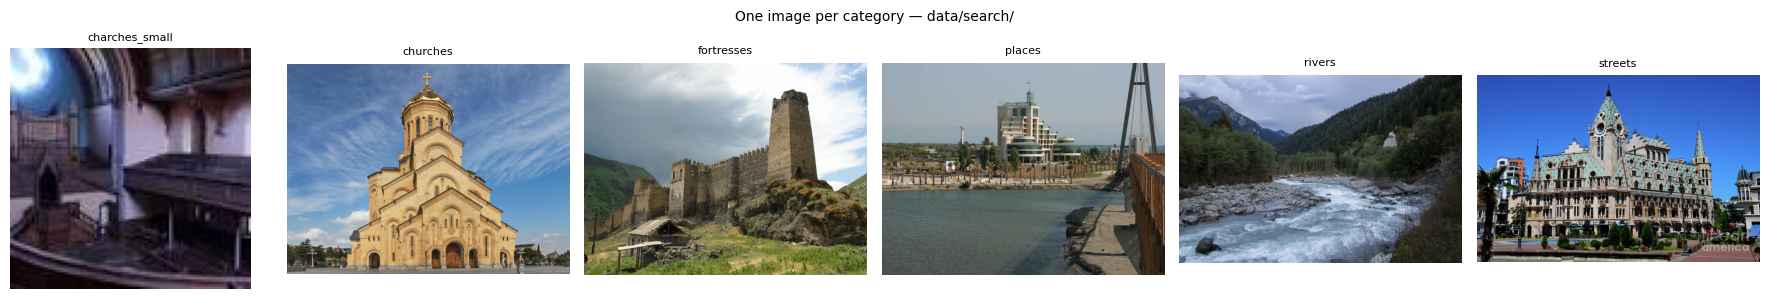

In [10]:
def load_search_images(search_dir: Path):
    """Load images from category sub-folders. Returns (paths, PIL images, category labels)."""
    paths, images, labels = [], [], []
    if not search_dir.exists():
        print(f"Search directory not found: {search_dir}")
        return paths, images, labels
    for cat_dir in sorted(search_dir.iterdir()):
        if not cat_dir.is_dir():
            continue
        for img_path in sorted(cat_dir.iterdir()):
            if img_path.suffix.lower() not in IMG_SUFFIXES:
                continue
            try:
                images.append(Image.open(img_path).convert("RGB"))
                paths.append(img_path)
                labels.append(cat_dir.name)
            except Exception:
                pass
    return paths, images, labels


search_paths, search_images, search_labels = load_search_images(SEARCH_DIR)
cats = sorted(set(search_labels))
print(f"Loaded {len(search_images)} images from {len(cats)} categories: {cats}")

# Show one sample per category
fig, axes = plt.subplots(1, len(cats), figsize=(3 * len(cats), 3))
if len(cats) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats):
    idx = search_labels.index(cat)
    ax.imshow(search_images[idx])
    ax.set_title(cat, fontsize=8)
    ax.axis("off")
plt.suptitle("One image per category — data/search/", fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
@no_grad()
def build_image_index(model, preprocess, images: List[Image.Image], device,
                       batch_size=32) -> np.ndarray:
    """Encode all images; return an (N, D) L2-normalised numpy array."""
    embs = []
    for i in tqdm(range(0, len(images), batch_size), desc="Indexing"):
        batch_t = torch.stack([preprocess(img) for img in images[i:i+batch_size]]).to(device)
        e = F.normalize(model.encode_image(batch_t), dim=-1)
        embs.append(e.cpu().numpy())
    return np.concatenate(embs, axis=0)


if search_images:
    print("Building CLIP ViT-B/32 image index…")
    b32_index = build_image_index(clip_b32, clip_b32_preprocess, search_images, DEVICE)
    print(f"Index shape: {b32_index.shape}  (num_images × embed_dim)")

Building CLIP ViT-B/32 image index…


Indexing:   0%|          | 0/5 [00:00<?, ?it/s]

Index shape: (157, 512)  (num_images × embed_dim)


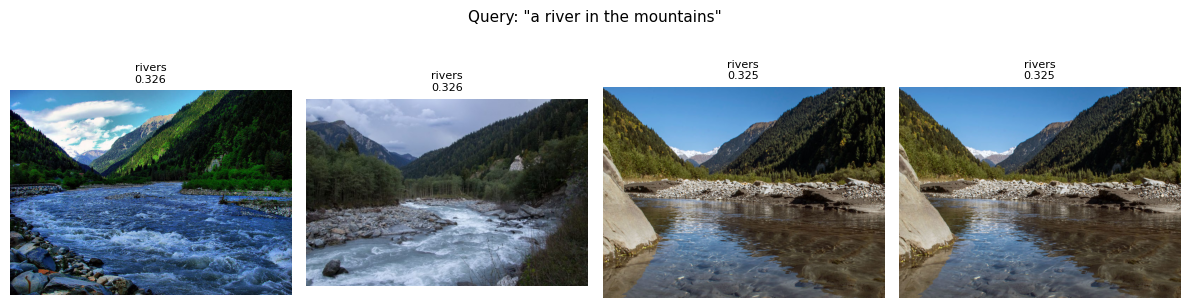

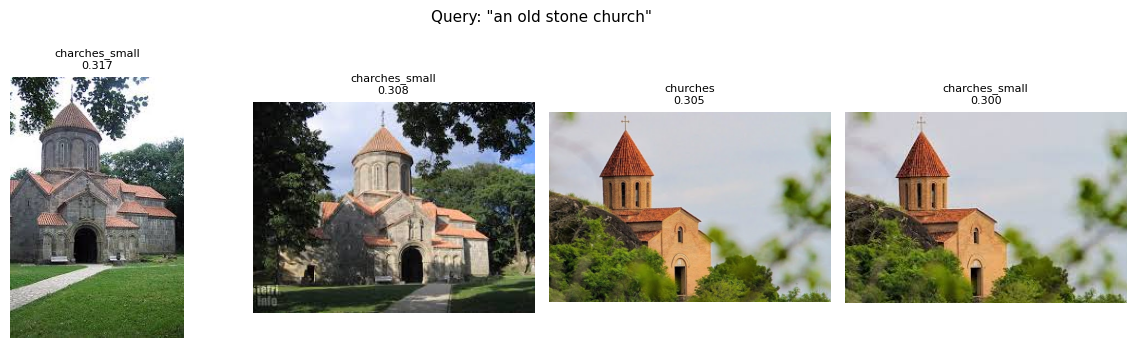

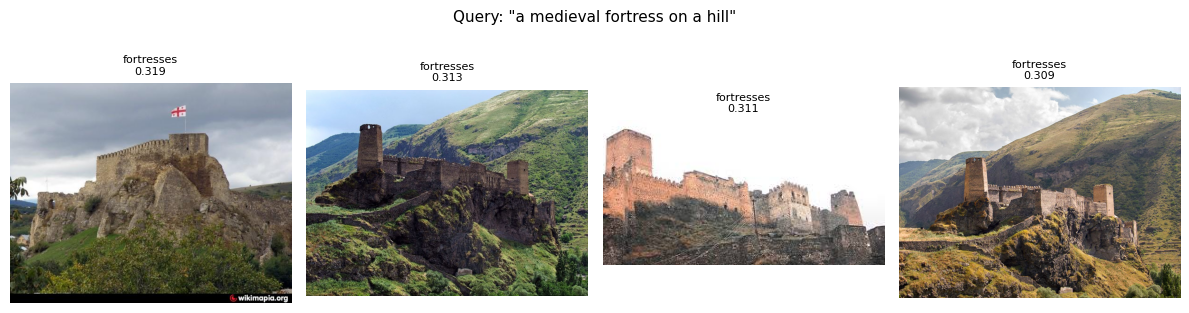

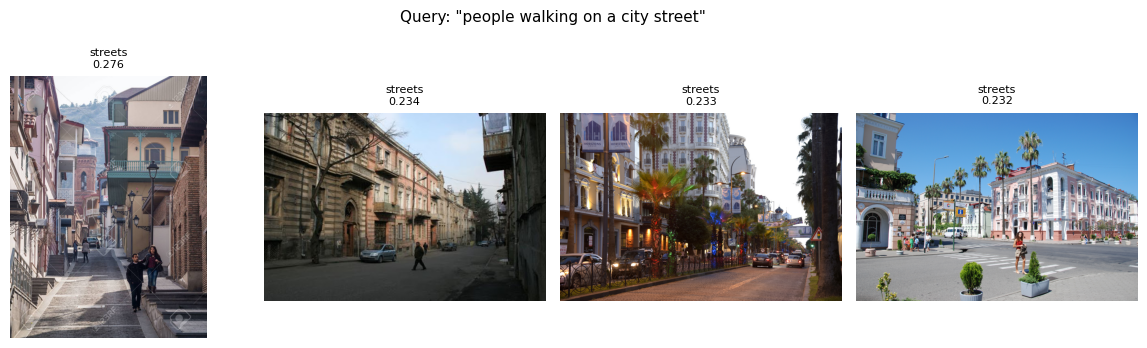

In [12]:
def text_image_search(query, model, tokenizer, index, images, labels, top_k=5):
    """Retrieve top-K images matching a text query."""
    tokens = tokenizer([query]).to(DEVICE)
    with no_grad():
        q = F.normalize(model.encode_text(tokens), dim=-1).cpu().numpy()
    scores  = (index @ q.T).squeeze()
    top_idx = scores.argsort()[::-1][:top_k]
    return [(float(scores[i]), images[i], labels[i]) for i in top_idx]


def show_results(results, query):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, (score, img, lbl) in zip(axes, results):
        ax.imshow(img)
        ax.set_title(f"{lbl}\n{score:.3f}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f'Query: "{query}"', fontsize=11)
    plt.tight_layout()
    plt.show()


if search_images and 'b32_index' in dir():
    for q in ["a river in the mountains",
              "an old stone church",
              "a medieval fortress on a hill",
              "people walking on a city street"]:
        results = text_image_search(q, clip_b32, clip_b32_tokenizer,
                                     b32_index, search_images, search_labels, top_k=4)
        show_results(results, q)

## 6. Jina-CLIP-v2 — Multilingual Cross-Modal Embeddings

### What Makes It Different?

| Feature | OpenCLIP ViT-B/32 | Jina-CLIP-v2 |
|---|---|---|
| Languages | English only | 89+ languages |
| Embedding dim | 512 | 1024 |
| Max resolution | 224 × 224 | 512 × 512 |
| Text encoder | GPT-style Transformer | JinaBERT (matryoshka) |
| Image encoder | ViT-B/32 | ViT-B/16 |
| OCR / document | Weak | Good |

The **matryoshka** training means you can safely truncate to 64/256 dims with small accuracy loss —
useful for storage-constrained retrieval systems.

In [13]:
JINA_MODEL_ID = "jinaai/jina-clip-v2"

print(f"Loading {JINA_MODEL_ID}…")
jina_model = SentenceTransformer(JINA_MODEL_ID, trust_remote_code=True)
jina_model = jina_model.to(DEVICE)
print(f"Loaded. Embedding dimension: {jina_model.get_sentence_embedding_dimension()}")

Loading jinaai/jina-clip-v2…


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/999 [00:00<?, ?it/s]

Loaded. Embedding dimension: None


### 6.1 Zero-Shot Classification with Jina-CLIP-v2

The `SentenceTransformer` API provides a unified `encode()` method that handles both PIL images and text.

In [14]:
def jina_zero_shot_accuracy(model, class_names, templates, max_samples=500) -> float:
    # Build text embeddings
    all_t = []
    for tmpl in templates:
        t = model.encode([tmpl.format(c) for c in class_names],
                          normalize_embeddings=True, batch_size=32)
        all_t.append(t)
    text_embs = np.mean(all_t, axis=0)
    text_embs /= np.linalg.norm(text_embs, axis=1, keepdims=True)

    cifar_test = CIFAR10(DATA_DIR, train=False, download=False)
    n = min(max_samples, len(cifar_test))
    pil_imgs = [cifar_test[i][0] for i in range(n)]
    labels   = np.array([cifar_test[i][1] for i in range(n)])

    img_embs = model.encode(pil_imgs, normalize_embeddings=True,
                             batch_size=16, show_progress_bar=True)
    preds    = (img_embs @ text_embs.T).argmax(axis=1)
    return int((preds == labels).sum()) / n


print("Running Jina-CLIP-v2 zero-shot (500 samples)…")
jina_acc = jina_zero_shot_accuracy(jina_model, CIFAR10_CLASSES, PROMPT_ENSEMBLE, max_samples=500)

print(f"\n{'Model':<22}  CIFAR-10 zero-shot")
print("─" * 42)
print(f"{'OpenCLIP ViT-B/32':<22}  {acc_ensemble*100:.1f}%")
print(f"{'OpenCLIP ViT-L/14':<22}  {acc_l14*100:.1f}%")
print(f"{'Jina-CLIP-v2':<22}  {jina_acc*100:.1f}%")

`use_return_dict` is deprecated! Use `return_dict` instead!


Running Jina-CLIP-v2 zero-shot (500 samples)…


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

ValueError: Modality 'image' is not supported by this SentenceTransformer model. Supported modalities: text

### 6.2 Multilingual Image Retrieval

The key advantage of Jina-CLIP-v2: you can query in **any of 89+ languages** and retrieve English-annotated images correctly.

In [15]:
if search_images:
    print("Building Jina-CLIP-v2 image index…")
    jina_index = jina_model.encode(
        search_images, batch_size=16,
        normalize_embeddings=True, show_progress_bar=True
    )
    print(f"Jina index shape: {jina_index.shape}")

    multilingual_queries = [
        ("English",  "a church surrounded by nature"),
        ("Georgian", "მდინარე მთებში"),          # "river in the mountains"
        ("French",   "une vieille forteresse"),   # "an old fortress"
        ("German",   "eine alte Steinkirche"),     # "an old stone church"
    ]
    for lang, q in multilingual_queries:
        q_emb  = jina_model.encode([q], normalize_embeddings=True)
        scores = (jina_index @ q_emb.T).squeeze()
        top_i  = scores.argsort()[::-1][:4]
        results = [(float(scores[i]), search_images[i], search_labels[i]) for i in top_i]
        show_results(results, f"[{lang}] {q}")

Building Jina-CLIP-v2 image index…


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

ValueError: Modality 'image' is not supported by this SentenceTransformer model. Supported modalities: text

## 7. Embedding Space Visualisation

CLIP's embedding space has a rich geometric structure: semantically similar images cluster together,
and text query embeddings land near the matching image clusters. We can expose this with **t-SNE**.

### Reading the Plot

- Each **dot** = one CIFAR-10 test image encoded by CLIP
- Colour = ground-truth class
- **★** = text prompt embedding for that class (`"a photo of a {class}."`)

Well-separated clusters confirm that CLIP has learned class-discriminative representations.
Notice that ★ text points land inside or very near the matching image cluster — this is the
mechanism behind zero-shot classification.

Extracting CLIP embeddings for 500 CIFAR-10 test images…
Running t-SNE (≈30 s)…


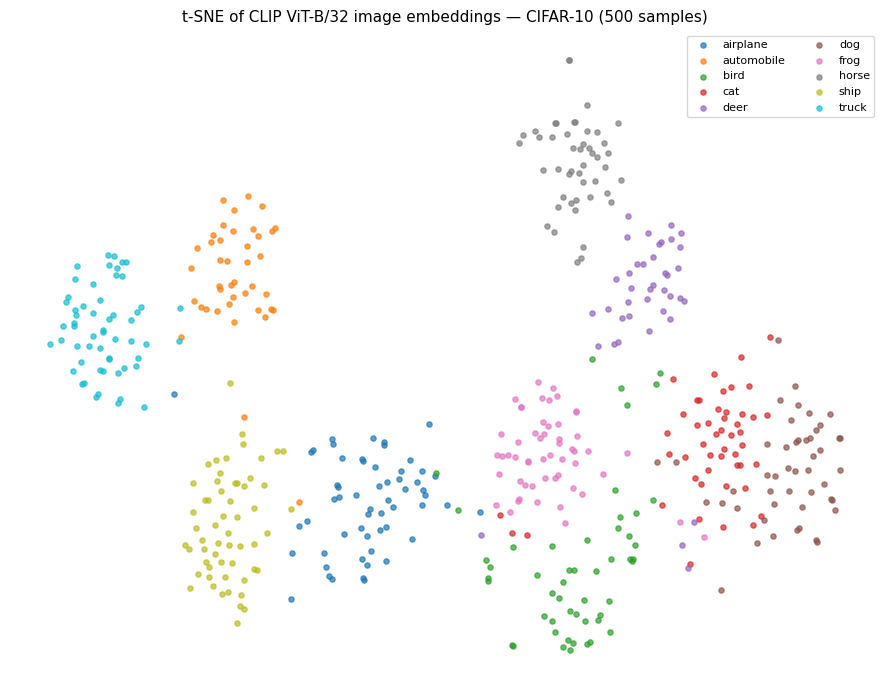

In [16]:
@no_grad()
def get_cifar_embeddings(model, preprocess, n=500, device=DEVICE):
    dataset = CIFAR10(DATA_DIR, train=False, download=False)
    imgs    = [dataset[i][0] for i in range(n)]
    labels  = np.array([dataset[i][1] for i in range(n)])
    batch_t = torch.stack([preprocess(img) for img in imgs]).to(device)
    embs    = F.normalize(model.encode_image(batch_t), dim=-1).cpu().numpy()
    return embs, labels


print("Extracting CLIP embeddings for 500 CIFAR-10 test images…")
embs_b32, cifar_lbls = get_cifar_embeddings(clip_b32, clip_b32_preprocess, n=500)

print("Running t-SNE (≈30 s)…")
embs_2d = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(embs_b32)

CMAP = plt.cm.get_cmap("tab10", 10)
fig, ax = plt.subplots(figsize=(9, 7))
for cid, cname in enumerate(CIFAR10_CLASSES):
    m = cifar_lbls == cid
    ax.scatter(embs_2d[m, 0], embs_2d[m, 1], color=CMAP(cid),
               label=cname, alpha=0.7, s=14)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.set_title("t-SNE of CLIP ViT-B/32 image embeddings — CIFAR-10 (500 samples)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

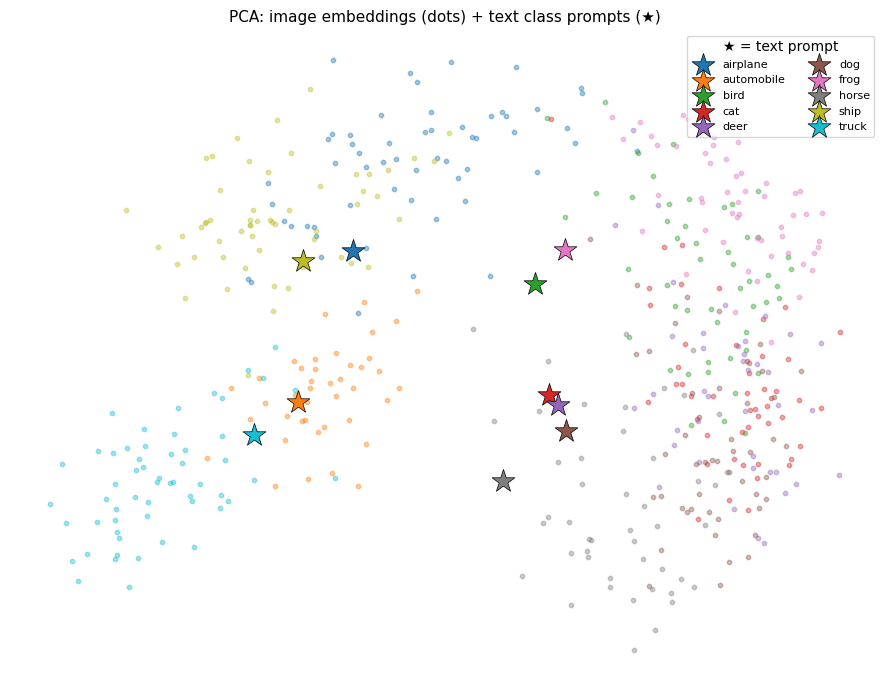

The ★ text embeddings land near matching image clusters — that's zero-shot classification!


In [17]:
# ── PCA: images + text class prompts in the same space ───────────────────────
text_np = build_text_embeddings(clip_b32, clip_b32_tokenizer, CIFAR10_CLASSES,
                                 ["a photo of a {}."], DEVICE).cpu().numpy()

combined_2d = PCA(n_components=2, random_state=42).fit_transform(
    np.vstack([embs_b32, text_np])
)
img_2d = combined_2d[:-10]
txt_2d = combined_2d[-10:]

fig, ax = plt.subplots(figsize=(9, 7))
for cid, cname in enumerate(CIFAR10_CLASSES):
    m = cifar_lbls == cid
    ax.scatter(img_2d[m, 0], img_2d[m, 1], color=CMAP(cid), alpha=0.4, s=10)
    ax.scatter(txt_2d[cid, 0], txt_2d[cid, 1], color=CMAP(cid),
               marker="*", s=300, edgecolors="black", linewidths=0.5,
               label=cname, zorder=5)
ax.legend(fontsize=8, ncol=2, title="★ = text prompt", loc="upper right")
ax.set_title("PCA: image embeddings (dots) + text class prompts (★)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()
print("The ★ text embeddings land near matching image clusters — that's zero-shot classification!")

## 8. Fused Generative VLMs

### 8.1 From Retrieval to Generation

Contrastive VLMs like CLIP answer *"which pre-defined class does this belong to?"*.  
Generative VLMs answer *"describe what you see"* in open-ended natural language.

### 8.2 LLaVA-Style Architecture

```
Image  ──►  Visual Encoder (CLIP ViT, frozen)
                    │
            Visual Projector (MLP, learnable)
                    │  visual tokens
                    ▼
 Text tokens ──►  LLM Decoder  ──►  Free-form text response
```

- **Visual Encoder**: pre-trained CLIP ViT — stays frozen during LLM training
- **Projector**: maps visual tokens into the LLM's vocabulary space (the key innovation in LLaVA)
- **LLM Decoder**: any causal language model (LLaMA, Qwen, Phi, SmolLM…)

### 8.3 Two-Stage Training

| Stage | What trains | Data |
|---|---|---|
| Stage 1 — Alignment | Projector only | ~595K image-caption pairs |
| Stage 2 — Instruction tuning | Projector + LLM | ~665K visual instruction samples |

### 8.4 Models We'll Run

| Model | Params | RAM (bfloat16) | Architecture |
|---|---|---|---|
| SmolVLM-256M | 256 M | ~0.5 GB | SigLIP + SmolLM2 |
| Qwen2-VL-2B | 2 B | ~4 GB | Custom ViT + Qwen2 |
| LLaVA-1.5-7B *(optional)* | 7 B | ~14 GB | CLIP ViT-L/14 + Vicuna-7B |

All fit on **M4 MacBook Pro 24 GB** unified memory.

## 9. SmolVLM-256M — A Tiny but Capable VLM

**SmolVLM** (HuggingFace, 2024) is built on the **Idefics3** architecture:
- Vision encoder: **SigLIP-400M** (Google's improved CLIP variant with sigmoid loss)
- Connector: pixel-shuffle + MLP projector
- Language model: **SmolLM2** (a compact causal LM trained on curated web data)

Despite 256M total parameters, SmolVLM handles captioning, VQA, and multi-turn dialogue reasonably well.

HuggingFace Transformers class: `Idefics3ForConditionalGeneration`

In [18]:
SMOLVLM_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"

print(f"Loading {SMOLVLM_ID}…")
smolvlm_proc  = AutoProcessor.from_pretrained(SMOLVLM_ID)
smolvlm_model = Idefics3ForConditionalGeneration.from_pretrained(
    SMOLVLM_ID,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to(DEVICE).eval()

n = sum(p.numel() for p in smolvlm_model.parameters()) / 1e6
print(f"Loaded SmolVLM-256M.  Parameters: {n:.0f}M")

Loading HuggingFaceTB/SmolVLM-256M-Instruct…


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loaded SmolVLM-256M.  Parameters: 256M


### 9.1 Generation Helper

The `apply_chat_template` method formats the prompt in the model's expected instruction format. We always trim the input tokens from the output so we only decode newly-generated text.

In [19]:
def smolvlm_generate(image: Image.Image, prompt: str,
                     max_new_tokens: int = 256) -> str:
    """Run SmolVLM on one image + prompt and return the generated text."""
    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": prompt},
    ]}]
    text   = smolvlm_proc.apply_chat_template(messages, add_generation_prompt=True)
    inputs = smolvlm_proc(text=text, images=[image], return_tensors="pt").to(DEVICE)

    with no_grad():
        out_ids = smolvlm_model.generate(**inputs, max_new_tokens=max_new_tokens,
                                          do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    return smolvlm_proc.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

### 9.2 Image Captioning

Captioning is the most straightforward VLM task: describe what is in the image.

=== SmolVLM-256M Image Captioning ===

Category : charches_small
Caption  : In this image we can see a building.



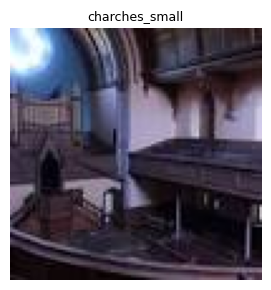

Category : charches_small
Caption  : In this image we can see a church. In the background there are trees.



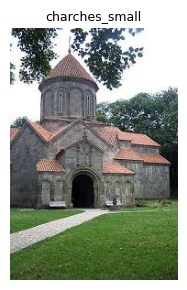

Category : places
Caption  : In this image we can see a bridge, a building, trees, poles, a flag, a building, a road, a group of people, a group of people, a group of trees, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a group of people, a



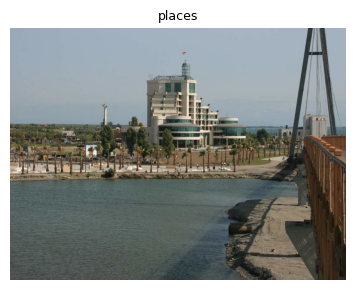

In [20]:
if search_images:
    n3 = len(search_images)
    sample_imgs = [search_images[i] for i in [0, n3 // 3, 2 * n3 // 3]]
    sample_cats = [search_labels[i] for i in [0, n3 // 3, 2 * n3 // 3]]
else:
    _ds = CIFAR10(DATA_DIR, train=False, download=False)
    sample_imgs = [_ds[i][0] for i in [0, 50, 100]]
    sample_cats = [CIFAR10_CLASSES[_ds[i][1]] for i in [0, 50, 100]]

CAPTION_PROMPT = "Describe this image in 2–3 sentences."

print("=== SmolVLM-256M Image Captioning ===\n")
for img, cat in zip(sample_imgs, sample_cats):
    caption = smolvlm_generate(img, CAPTION_PROMPT)
    print(f"Category : {cat}")
    print(f"Caption  : {caption}\n")

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img)
    ax.set_title(cat, fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### 9.3 Visual Question Answering (VQA)

VQA tests whether the model can accurately answer targeted questions about image content.

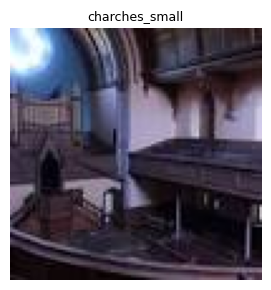

=== VQA on: charches_small ===

Q: What is the main subject of this image?
A: The image depicts an old, historical building with a grand architectural design. The building is characterized by its large, arched windows and a grand staircase leading up to the entrance. The windows are framed with dark wood, and the walls are painted in a light color, possibly white or off-white. The staircase is made of dark wood, and it leads up to a raised platform or balcony. The building has a large arched doorway at the front, which is flanked by two smaller windows on either side.

The building is surrounded by a large, arched entrance with a large, circular archway. The archway is

Q: What time of day does this appear to be taken?
A: The time of day appears to be either early morning or late afternoon.

Q: What colours dominate this image?
A: The image is dominated by a large, ornate building with a curved, arched entrance. The building has a classical architectural style, with a series of arches 

In [21]:
VQA_QUESTIONS = [
    "What is the main subject of this image?",
    "What time of day does this appear to be taken?",
    "What colours dominate this image?",
    "Is this scene outdoors or indoors?",
]

if sample_imgs:
    img_vqa, cat_vqa = sample_imgs[0], sample_cats[0]
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img_vqa)
    ax.set_title(cat_vqa, fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"=== VQA on: {cat_vqa} ===\n")
    for q in VQA_QUESTIONS:
        a = smolvlm_generate(img_vqa, q, max_new_tokens=128)
        print(f"Q: {q}")
        print(f"A: {a}\n")

### 9.4 Multi-Turn Conversation

Instruction-tuned VLMs support multi-turn dialogue — follow-up questions stay grounded on the original image.

> **Implementation note**: we rebuild the full conversation history on each turn.
> In production, use `past_key_values` caching to avoid re-computing the context.

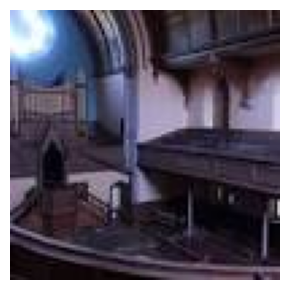

=== Multi-Turn Conversation ===

User : What do you see in this image? Give a short description.
Bot  : This image depicts an old, historical building with a grand architectural design. The building appears to be a church or a cathedral, as indicated by the large, ornate arches and the pointed arches that frame the entrance. The walls are painted in a light color, and the roof is covered with a decorative roof. The windows are large and rectangular, and they are framed with dark wood. The entrance to the church is flanked by columns, and there is a large, arched doorway leading into the church. The floor of the church is made of stone, and there are several benches or seats in front of the entrance.

The architectural style of the building is Gothic, characterized by its pointed arches and ribbed vaults. The use of dark wood and the intricate details on the walls suggest that this is a significant religious structure, possibly a cathedral or a church. The overall impression is one of g

In [22]:
def smolvlm_chat(image: Image.Image, history: List[dict],
                 max_new_tokens: int = 256) -> str:
    """Multi-turn chat. history is a list of {role, content} dicts.
    The image placeholder appears only in the first user turn.
    """
    text   = smolvlm_proc.apply_chat_template(history, add_generation_prompt=True)
    inputs = smolvlm_proc(text=text, images=[image], return_tensors="pt").to(DEVICE)
    with no_grad():
        out_ids = smolvlm_model.generate(**inputs, max_new_tokens=max_new_tokens,
                                          do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    return smolvlm_proc.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


if sample_imgs:
    img_chat = sample_imgs[0]
    history  = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": "What do you see in this image? Give a short description."},
    ]}]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img_chat)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("=== Multi-Turn Conversation ===\n")
    r1 = smolvlm_chat(img_chat, history)
    print(f"User : {history[0]['content'][1]['text']}")
    print(f"Bot  : {r1}\n")

    history.append({"role": "assistant", "content": r1})
    q2 = "What mood or atmosphere does this image convey? One sentence."
    history.append({"role": "user", "content": [{"type": "text", "text": q2}]})

    r2 = smolvlm_chat(img_chat, history)
    print(f"User : {q2}")
    print(f"Bot  : {r2}")

## 10. Qwen2-VL-2B — A Powerful Compact VLM

**Qwen2-VL** (Alibaba, 2024) significantly outperforms models of similar size on standard benchmarks.

### Key Innovations

- **Native dynamic resolution**: processes images at their actual resolution instead of forcing a fixed 224×224
  resize — much better for detail-rich or high-resolution inputs
- **RoPE-2D**: position encodings adapted for 2D spatial layout rather than flat 1D sequences
- **Strong OCR**: effectively reads text embedded in images (signs, documents, screenshots)
- **Video support**: can reason over multiple frames

HuggingFace Transformers class: `Qwen2VLForConditionalGeneration`

In [ ]:
QWEN_ID = "Qwen/Qwen2-VL-2B-Instruct"

print(f"Loading {QWEN_ID}…")
qwen_proc  = AutoProcessor.from_pretrained(QWEN_ID)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_ID,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to(DEVICE).eval()

n = sum(p.numel() for p in qwen_model.parameters()) / 1e6
print(f"Loaded Qwen2-VL-2B.  Parameters: {n:.0f}M")

Loading Qwen/Qwen2-VL-2B-Instruct…


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def qwen_generate(image: Image.Image, prompt: str,
                  max_new_tokens: int = 256) -> str:
    """Run Qwen2-VL on one image + prompt."""
    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": prompt},
    ]}]
    text   = qwen_proc.apply_chat_template(messages, tokenize=False,
                                            add_generation_prompt=True)
    inputs = qwen_proc(text=[text], images=[image], return_tensors="pt").to(DEVICE)
    with no_grad():
        out_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens,
                                       do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    return qwen_proc.batch_decode(trimmed, skip_special_tokens=True)[0].strip()

### 10.1 Detailed Scene Understanding

With 2B parameters Qwen2-VL produces substantially richer descriptions than SmolVLM-256M.

In [ ]:
if sample_imgs:
    print("=== Qwen2-VL-2B Scene Understanding ===\n")
    for img, cat in zip(sample_imgs, sample_cats):
        desc = qwen_generate(img,
            "Describe this image in detail. Include objects, setting, colours, and notable features.")
        print(f"Category : {cat}")
        print(f"Qwen2-VL : {desc}\n")

### 10.2 CLIP vs Qwen2-VL: Comparing Two Paradigms

This side-by-side comparison illustrates the fundamental difference between contrastive and generative VLMs:
- **CLIP** gives a ranked probability distribution over a fixed set of labels
- **Qwen2-VL** gives free-form language that can express nuance CLIP cannot

In [ ]:
if sample_imgs and 'b32_index' in dir():
    img_cmp, cat_cmp = sample_imgs[0], sample_cats[0]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img_cmp)
    ax.set_title(f"True: {cat_cmp}", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # ── CLIP zero-shot scores ──────────────────────────────────────────────────
    search_cls = sorted(set(search_labels)) if search_labels else CIFAR10_CLASSES
    toks = clip_b32_tokenizer([f"a photo of {c}" for c in search_cls]).to(DEVICE)
    with no_grad():
        ie = F.normalize(clip_b32.encode_image(
            clip_b32_preprocess(img_cmp).unsqueeze(0).to(DEVICE)), dim=-1)
        te = F.normalize(clip_b32.encode_text(toks), dim=-1)
    probs = (ie @ te.T).softmax(dim=-1).squeeze().cpu()

    print("CLIP zero-shot top-5:")
    for cls, p in sorted(zip(search_cls, probs.tolist()), key=lambda x: -x[1])[:5]:
        print(f"  {cls:<20}  {p*100:.1f}%")

    print("\nQwen2-VL free-form description:")
    desc = qwen_generate(img_cmp,
        "What kind of scene or place is shown in this image? Name and briefly describe it.")
    print(f"  {desc}")

## 11. LLaVA-1.5-7B  *(Optional — needs ≥ 16 GB RAM)*

**LLaVA 1.5** is the most widely cited open-source generative VLM baseline.
It connects **CLIP ViT-L/14@336** (fine image encoder) to **Vicuna-7B** via a two-layer MLP projector.

On **M4 MacBook Pro 24 GB** it loads in `float16` and uses ~14 GB of unified memory.
On GPUs with < 16 GB, use 4-bit quantisation via `bitsandbytes`.

The first run downloads ~14 GB of weights — ensure you have bandwidth and disk space.

In [ ]:
LLAVA_ID = "llava-hf/llava-1.5-7b-hf"

# Uncomment the block below to load LLaVA — requires ≥ 16 GB RAM
# ─────────────────────────────────────────────────────────────────────────────
# print(f"Loading {LLAVA_ID}…")
# llava_proc  = AutoProcessor.from_pretrained(LLAVA_ID)
# llava_model = LlavaForConditionalGeneration.from_pretrained(
#     LLAVA_ID,
#     torch_dtype=torch.float16,
#     low_cpu_mem_usage=True,
# ).to(DEVICE).eval()
# print(f"Loaded. Params: {sum(p.numel() for p in llava_model.parameters())/1e6:.0f}M")
print("LLaVA section is commented out. Uncomment to run on machines with ≥ 16 GB RAM.")

In [ ]:
def llava_generate(image: Image.Image, prompt: str,
                   max_new_tokens: int = 256) -> str:
    """
    Run LLaVA-1.5 on one image + prompt.

    LLaVA-1.5 requires this exact prompt format:
        USER: <image>\n<your question>\nASSISTANT:
    The special <image> token is replaced by visual patch tokens internally.
    """
    full_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"
    inputs = llava_proc(text=full_prompt, images=image, return_tensors="pt").to(DEVICE)
    with no_grad():
        out_ids = llava_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return llava_proc.decode(out_ids[0][2:], skip_special_tokens=True).strip()


# ── Uncomment to run LLaVA experiments ────────────────────────────────────────
# if sample_imgs and 'llava_model' in dir():
#     for img, cat in zip(sample_imgs, sample_cats):
#         desc = llava_generate(img, "Describe this image in 2–3 sentences.")
#         print(f"Category : {cat}")
#         print(f"LLaVA    : {desc}\n")
print("Experiments commented out — uncomment after loading the model above.")

## 12. Summary & Comparison

### 12.1 Architecture Families

```
CONTRASTIVE VLMs (CLIP family)
  OpenCLIP ViT-B/32  ──  ViT-B/patch32  +  GPT text  →  512-dim shared space
  OpenCLIP ViT-L/14  ──  ViT-L/patch14  +  GPT text  →  768-dim shared space
  Jina-CLIP-v2       ──  ViT-B/patch16  +  JinaBERT   →  1024-dim matryoshka

GENERATIVE VLMs (LLaVA family)
  SmolVLM-256M       ──  SigLIP-400M  →  projector  →  SmolLM2-135M
  Qwen2-VL-2B        ──  ViT (dynamic) →  MLP        →  Qwen2-1.5B
  LLaVA-1.5-7B       ──  CLIP ViT-L/14@336  →  MLP   →  Vicuna-7B
```

### 12.2 When to Use Which

| Task | Best choice | Reason |
|---|---|---|
| Zero-shot classification | OpenCLIP ViT-L/14 | Highest accuracy, fast |
| Multilingual retrieval | Jina-CLIP-v2 | 89+ languages, 1024-dim |
| Fast on-device captioning | SmolVLM-256M | Trivially small |
| Balanced VQA + captioning | Qwen2-VL-2B | Best quality/size |
| Classic VLM baseline | LLaVA-1.5-7B | Well-studied |
| Document / OCR | Qwen2-VL-2B | Strong native OCR |

### 12.3 Key Conceptual Takeaways

1. **Contrastive training** creates a shared semantic space — no class-specific supervision,
   enabling zero-shot transfer to arbitrary label sets.

2. **Prompt engineering matters**: ensemble prompts consistently beat single templates;
   natural-language descriptions beat raw class names.

3. **Scale improves CLIP**: ViT-L/14 substantially outperforms ViT-B/32 on the same training data.

4. **Fused VLMs go further**: they understand context, spatial relationships, and fine-grained detail
   that CLIP's fixed class list cannot express.

5. **Tiny VLMs are real**: SmolVLM-256M does meaningful captioning and VQA at 256M parameters,
   making on-device (phone/edge) deployment viable.

In [ ]:
print(f"{'Model':<22}  {'Type':<14}  {'Params':>7}  {'RAM(bfloat16)':>13}  {'CIFAR-10':>10}  Notes")
print("─" * 100)
rows = [
    ("OpenCLIP ViT-B/32", "Contrastive",  "~150M",  "~0.6 GB",  f"{acc_ensemble*100:.1f}%",  "Fast; good baseline"),
    ("OpenCLIP ViT-L/14", "Contrastive",  "~428M",  "~1.7 GB",  f"{acc_l14*100:.1f}%",       "Best contrastive acc"),
    ("Jina-CLIP-v2",      "Contrastive",  "~865M",  "~3.3 GB",  f"{jina_acc*100:.1f}%",      "Multilingual; 1024d"),
    ("SmolVLM-256M",      "Generative",   "~256M",  "~0.5 GB",  "N/A",                        "Tiny; VQA + chat"),
    ("Qwen2-VL-2B",       "Generative",   "~2B",    "~4.0 GB",  "N/A",                        "Best quality/size"),
    ("LLaVA-1.5-7B",      "Generative",   "~7B",    "~14 GB",   "N/A",                        "Classic baseline"),
]
for name, typ, params, ram, acc, notes in rows:
    print(f"{name:<22}  {typ:<14}  {params:>7}  {ram:>13}  {acc:>10}  {notes}")

In [ ]:
print("Tutorial complete!")
print()
print("You have run:")
print("  ✓ OpenCLIP ViT-B/32 and ViT-L/14 zero-shot classification")
print("  ✓ Prompt engineering: plain / single template / ensemble")
print("  ✓ Text → image retrieval on local georegion dataset")
print("  ✓ Jina-CLIP-v2 multilingual retrieval")
print("  ✓ t-SNE + PCA embedding space visualisation")
print("  ✓ SmolVLM-256M: captioning, VQA, multi-turn chat")
print("  ✓ Qwen2-VL-2B: detailed description + paradigm comparison")
print()
print("Next steps:")
print("  → Uncomment Section 11 to run LLaVA-1.5-7B")
print("  → Try Qwen2-VL on document images (screenshots, receipts)")
print("  → Build a RAG pipeline: CLIP retrieval + Qwen2-VL generation")